In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
LOG_DIR = 'logs'
RUNS_TO_ANALYSE = {
    "CEM": 'run_2026-01-06_20-32-49',
    "RandomShooting": 'run_2026-01-06_20-31-12',
    'MPPI': 'run_2026-01-06_20-31-40'
}
TARGET_LOCATION = 5.0 ## should log this in df

df = pd.DataFrame()
for algo, run in RUNS_TO_ANALYSE.items():
    raw_df = (
        pd.read_csv(f"{LOG_DIR}/{algo}/{run}/results.csv")
        .assign(algo=algo, target_location = TARGET_LOCATION)
        .assign(distance_to_target = lambda x: np.abs(x['positions'] - x['target_location']))
    )
    df = pd.concat([df, raw_df])

df

,Unnamed: 0,timestep,positions,velocities,fuel,rewards,actions,algo,target_location,distance_to_target
0,0,0,0.024331,0.486614,0.495388,-5.826648,0.922485,CEM,5.0,4.975669
1,1,1,0.070260,0.918596,0.491053,-5.681110,0.866816,CEM,5.0,4.929740
2,2,2,0.134830,1.291400,0.487029,-5.513043,0.804906,CEM,5.0,4.865170
3,3,3,0.219925,1.701892,0.482863,-5.474210,0.833147,CEM,5.0,4.780075
4,4,4,0.319940,2.000293,0.479376,-5.166614,0.697534,CEM,5.0,4.680060
...,...,...,...,...,...,...,...,...,...,...
95,95,95,4.899486,0.113375,0.258306,-0.179176,-0.280467,MPPI,5.0,0.100514
96,96,96,4.894072,-0.108274,0.255352,-0.455190,-0.590984,MPPI,5.0,0.105928
97,97,97,4.889764,-0.086168,0.253416,-0.260052,-0.387060,MPPI,5.0,0.110236
98,98,98,4.904438,0.293492,0.252976,-0.103328,-0.088126,MPPI,5.0,0.095562


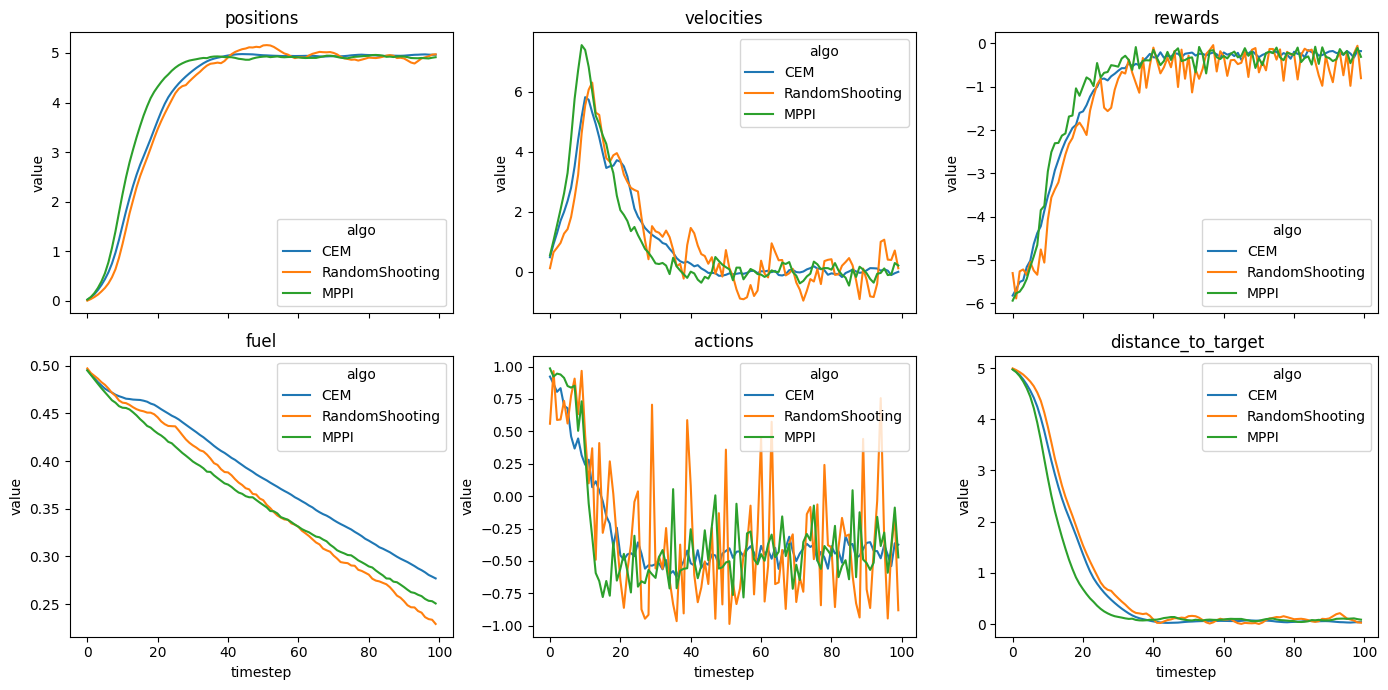

In [13]:
to_plot = df.drop('Unnamed: 0', axis=1).melt(id_vars=['algo', 'timestep'])

fig, ax = plt.subplots(2,3, figsize=(14, 7), sharex=True)
ax = ax.flatten()
cols_to_plot =['positions', 'velocities', 'rewards', 'fuel', 'actions', 'distance_to_target'] 
for i, col in enumerate(cols_to_plot):
    sns.lineplot(
        data=to_plot.query('variable == @col'),
        x = 'timestep',
        y = 'value',
        hue='algo',
        ax=ax[i]
    )
    ax[i].set_title(col)
plt.tight_layout()
plt.show();

<Axes: xlabel='algo'>

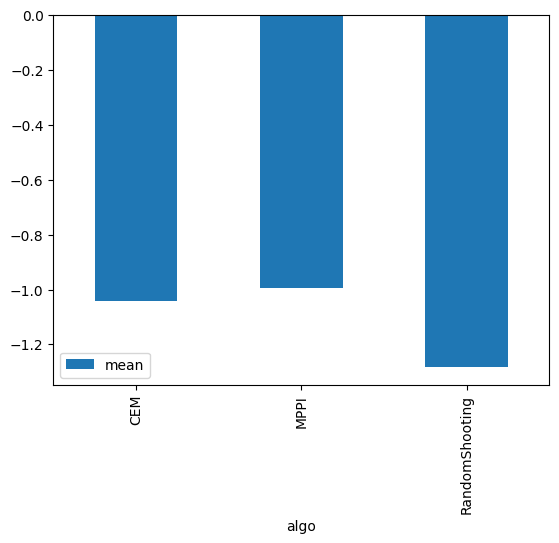

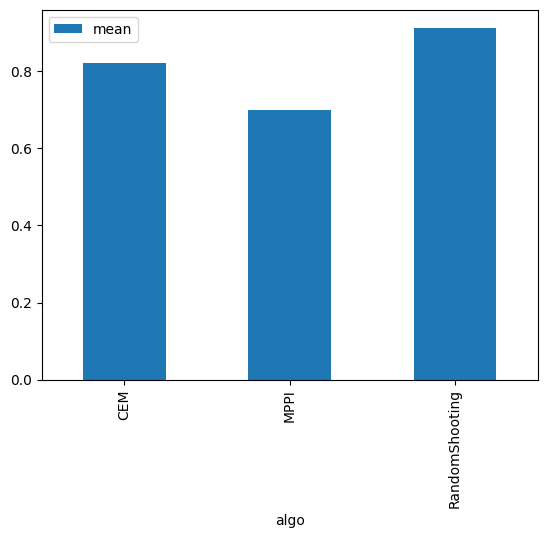

In [24]:
aggregate_results = df.groupby('algo').agg({'rewards': ['mean'], 'distance_to_target':['mean']})
aggregate_results['rewards'].plot(kind='bar')
aggregate_results['distance_to_target'].plot(kind='bar')

<Axes: xlabel='timestep_min', ylabel='timestep_count'>

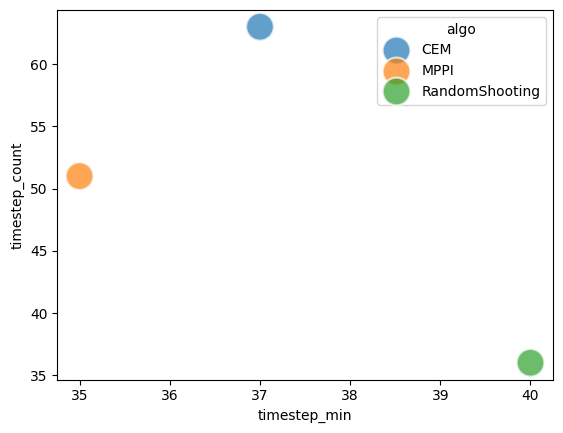

In [39]:
df['reach_target'] = (df['distance_to_target'] < 0.1)*1
out = (
    df
    .groupby(['algo', 'reach_target'], as_index=False)
    .agg(
        timestep_min=('timestep', 'min'),
        timestep_count=('timestep', 'count')
    )
)


sns.scatterplot(
    data=out.query('reach_target==1'), 
    x='timestep_min', 
    y='timestep_count', 
    hue='algo',
    s = 400,
    alpha = 0.7
)